### Lab 6 - Spinning & Rolling Objects

**Student:** Zaki Daouk  
**Date:** 2026-10-04

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Part A — The Physical Pendulum

In [2]:
def moment_of_inertia(masses, positions, axis):
    """I about a given axis point for a set of point masses."""
    total = 0.0
    for m, r in zip(masses, positions):
        total += m * np.sum((np.asarray(r) - np.asarray(axis))**2)
    return total

In [3]:
def rotate_step(theta, omega, torque, I, dt):
    """Euler-Cromer step for rotation."""
    alpha = torque / I
    omega = omega + alpha * dt      # angular velocity first
    theta = theta + omega * dt      # then angle (Euler-Cromer)
    return theta, omega

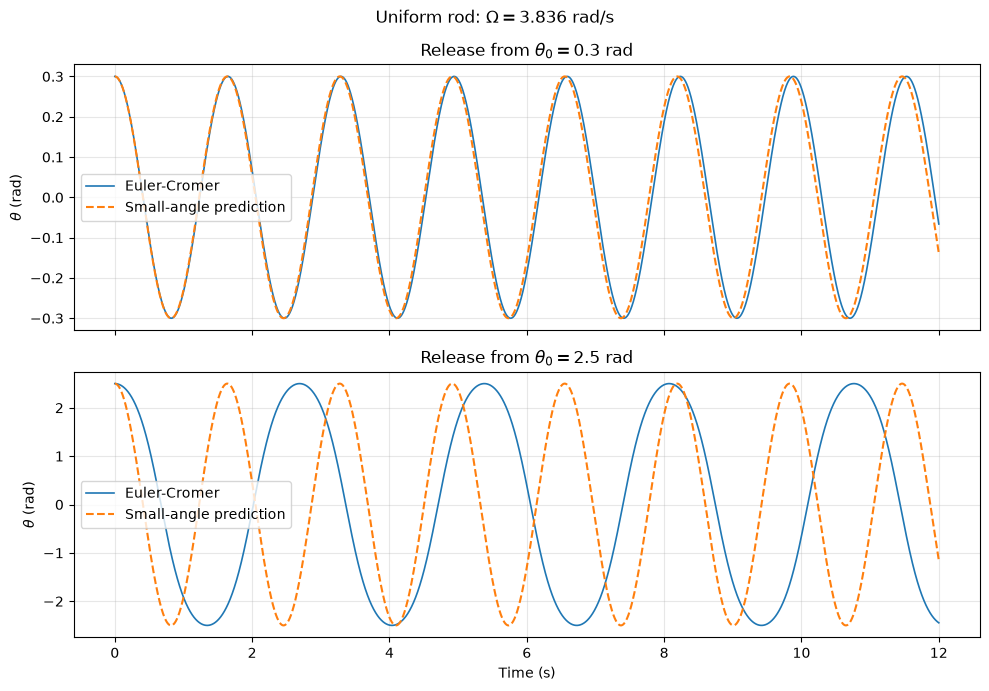

In [4]:
m, g, L = 1.0, 9.81, 1.0
d = L / 2
I = (1 / 3) * m * L**2
Omega = np.sqrt(m * g * d / I)

def simulate(theta0, t_final=12.0, dt=0.001):
    times = np.arange(0.0, t_final + dt, dt)
    angles = np.empty_like(times)
    angular_velocities = np.empty_like(times)
    angles[0], angular_velocities[0] = theta0, 0.0

    for index in range(len(times) - 1):
        torque = -m * g * d * np.sin(angles[index])
        angles[index + 1], angular_velocities[index + 1] = rotate_step(
            angles[index], angular_velocities[index], torque, I, dt
        )
    return times, angles

results = {}
for theta0 in (0.3, 2.5):
    times, angles = simulate(theta0)
    small_angle = theta0 * np.cos(Omega * times)
    results[theta0] = times, angles, small_angle

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for axis, theta0 in zip(axes, (0.3, 2.5)):
    times, angles, small_angle = results[theta0]
    axis.plot(times, angles, label="Euler-Cromer", linewidth=1.2)
    axis.plot(times, small_angle, "--", label="Small-angle prediction")
    axis.set_ylabel(r"$\theta$ (rad)")
    axis.set_title(fr"Release from $\theta_0 = {theta0}$ rad")
    axis.grid(alpha=0.3)
    axis.legend()

axes[-1].set_xlabel("Time (s)")
fig.suptitle(fr"Uniform rod: $\Omega = {Omega:.3f}$ rad/s")
fig.tight_layout()
plt.show()

### Interpretation

For the small release, $\sin\theta \approx \theta$, so the rod behaves like a harmonic oscillator with

$$
\theta(t) = \theta_0\cos(\Omega t),
\qquad
\Omega = \sqrt{\frac{mgd}{I}} = \sqrt{\frac{3g}{2L}}.
$$

For the large release, the Euler-Cromer solution has a **longer period** than the small-angle prediction. The curves gradually move out of phase because the small-angle formula keeps the constant frequency $\Omega$, while the exact torque $-mgd\sin\theta$ is weaker than $-mgd\theta$ at large angles. This is the same nonlinear pendulum effect seen in Lab 3: the period increases with amplitude, so the small-angle approximation becomes less accurate as the release angle grows.

### Part B — The Rolling Race

In [5]:
def rolling_accel(theta_incline, c, g=9.81):
    """Linear acceleration down an incline for a rolling body.
    c = I/(m R^2): hoop=1, disk=0.5, sphere=0.4."""
    return g * np.sin(theta_incline) / (1 + c)

Finishing order:
1. Sphere: 2.389 s
2. Disk: 2.473 s
3. Hoop: 2.856 s


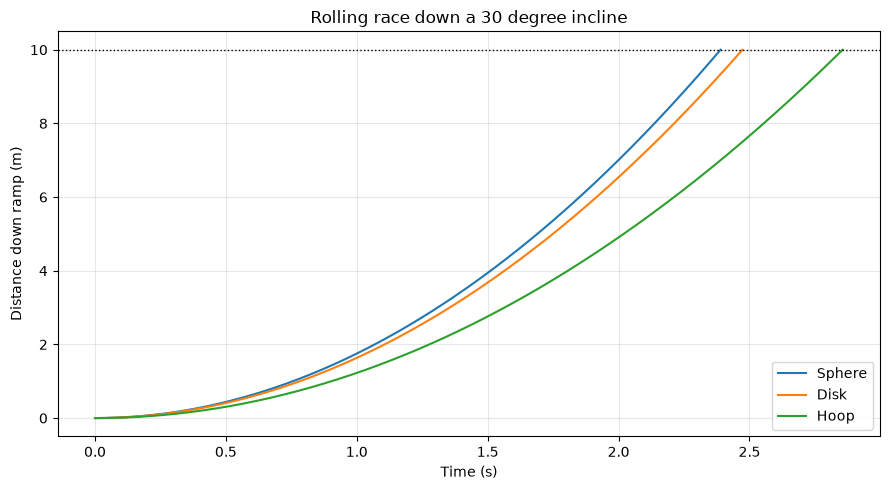

Energy check: max relative variation = 4.35e-16
Final rotational-energy fraction for the disk = 0.333
Expected fraction c/(1+c) = 0.333


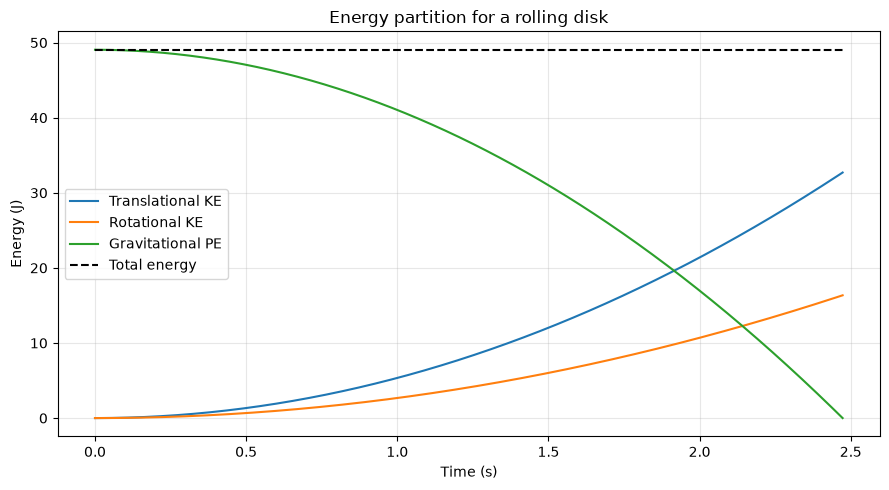

In [6]:
incline_angle = np.deg2rad(30.0)
ramp_length = 10.0

bodies = {
    "Sphere": {"c": 0.4, "mass": 1.0, "radius": 0.20},
    "Disk": {"c": 0.5, "mass": 1.0, "radius": 0.20},
    "Hoop": {"c": 1.0, "mass": 1.0, "radius": 0.20},
}

finish_times = {}
trajectories = {}
for name, body in bodies.items():
    acceleration = rolling_accel(incline_angle, body["c"])
    finish_time = np.sqrt(2 * ramp_length / acceleration)
    time = np.linspace(0.0, finish_time, 500)
    position = 0.5 * acceleration * time**2
    finish_times[name] = finish_time
    trajectories[name] = time, position

print("Finishing order:")
for place, (name, finish_time) in enumerate(
    sorted(finish_times.items(), key=lambda item: item[1]), start=1
):
    print(f"{place}. {name}: {finish_time:.3f} s")

fig_race, axis_race = plt.subplots(figsize=(9, 5))
for name, (time, position) in trajectories.items():
    axis_race.plot(time, position, label=name)
axis_race.axhline(ramp_length, color="black", linestyle=":", linewidth=1)
axis_race.set_xlabel("Time (s)")
axis_race.set_ylabel("Distance down ramp (m)")
axis_race.set_title("Rolling race down a 30 degree incline")
axis_race.grid(alpha=0.3)
axis_race.legend()
fig_race.tight_layout()
plt.show()

energy_body = bodies["Disk"]
energy_acceleration = rolling_accel(incline_angle, energy_body["c"])
energy_time = np.linspace(0.0, finish_times["Disk"], 500)
energy_position = 0.5 * energy_acceleration * energy_time**2
energy_velocity = energy_acceleration * energy_time
energy_height = (ramp_length - energy_position) * np.sin(incline_angle)

translational_ke = 0.5 * energy_body["mass"] * energy_velocity**2
rotational_ke = 0.5 * energy_body["c"] * energy_body["mass"] * energy_velocity**2
gravitational_pe = energy_body["mass"] * g * energy_height
total_energy = translational_ke + rotational_ke + gravitational_pe
initial_energy = gravitational_pe[0]
rotation_fraction = rotational_ke[-1] / (translational_ke[-1] + rotational_ke[-1])

print(f"Energy check: max relative variation = {np.ptp(total_energy) / initial_energy:.2e}")
print(f"Final rotational-energy fraction for the disk = {rotation_fraction:.3f}")
print(f"Expected fraction c/(1+c) = {energy_body['c'] / (1 + energy_body['c']):.3f}")

fig_energy, axis_energy = plt.subplots(figsize=(9, 5))
axis_energy.plot(energy_time, translational_ke, label="Translational KE")
axis_energy.plot(energy_time, rotational_ke, label="Rotational KE")
axis_energy.plot(energy_time, gravitational_pe, label="Gravitational PE")
axis_energy.plot(energy_time, total_energy, "k--", label="Total energy")
axis_energy.set_xlabel("Time (s)")
axis_energy.set_ylabel("Energy (J)")
axis_energy.set_title("Energy partition for a rolling disk")
axis_energy.grid(alpha=0.3)
axis_energy.legend()
fig_energy.tight_layout()
plt.show()

### Analysis

For rolling without slipping,

$$
a = \frac{g\sin\theta}{1+c},
\qquad c = \frac{I}{mR^2}.
$$

The sphere has the smallest shape factor ($c=0.4$), so it has the largest acceleration and finishes first. The disk follows with $c=0.5$, and the hoop is slowest because $c=1$. Therefore the order is **sphere, disk, hoop**.

The mass and radius cancel because the gravitational driving torque and rotational inertia both scale with mass and radius in the same way. Equivalently, the rolling equation contains $I=c mR^2$, and after using $v=R\omega$, the factors $m$ and $R$ leave only the dimensionless shape factor $c$. Thus same-shaped objects, such as a bowling ball and a marble, tie when they roll from rest down the same ramp.

For the disk, the final energy fractions are

$$
\frac{K_{\mathrm{rot}}}{K_{\mathrm{trans}}+K_{\mathrm{rot}}}
= \frac{c}{1+c} = \frac{1}{3},
\qquad
\frac{K_{\mathrm{trans}}}{K_{\mathrm{trans}}+K_{\mathrm{rot}}}
= \frac{1}{1+c} = \frac{2}{3}.
$$

The gravitational potential energy decreases by exactly the amount gained as translational plus rotational kinetic energy, so the total mechanical energy remains constant.

### Part C — Angular Momentum Conservation

Relative change in angular momentum: 1.11e-16
Initial angular speed: 2.00 rad/s
Final angular speed: 16.33 rad/s


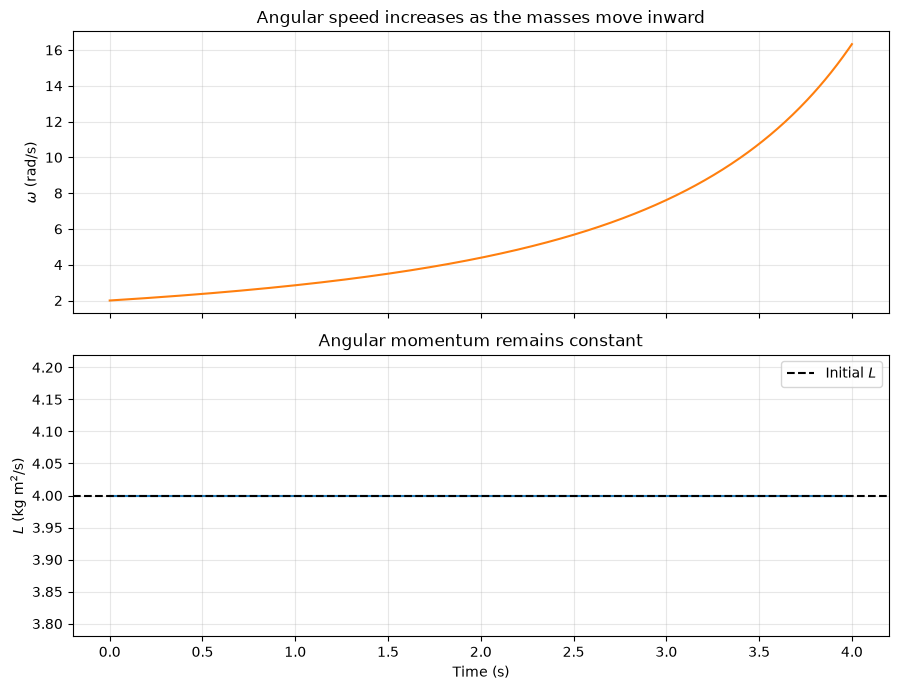

In [7]:
mass_each = 1.0
radius_initial = 1.0
radius_final = 0.35
angular_speed_initial = 2.0

conservation_time = np.linspace(0.0, 4.0, 500)
radius = np.linspace(radius_initial, radius_final, conservation_time.size)
moment_of_inertia = 2 * mass_each * radius**2
initial_moment_of_inertia = moment_of_inertia[0]
angular_momentum_initial = initial_moment_of_inertia * angular_speed_initial
angular_speed = angular_momentum_initial / moment_of_inertia
angular_momentum = moment_of_inertia * angular_speed

relative_change = np.ptp(angular_momentum) / angular_momentum_initial
print(f"Relative change in angular momentum: {relative_change:.2e}")
print(f"Initial angular speed: {angular_speed[0]:.2f} rad/s")
print(f"Final angular speed: {angular_speed[-1]:.2f} rad/s")

fig_momentum, (axis_speed, axis_momentum) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axis_speed.plot(conservation_time, angular_speed, color="tab:orange")
axis_speed.set_ylabel(r"$\omega$ (rad/s)")
axis_speed.set_title("Angular speed increases as the masses move inward")
axis_speed.grid(alpha=0.3)

axis_momentum.plot(conservation_time, angular_momentum, color="tab:blue")
axis_momentum.axhline(angular_momentum_initial, color="black", linestyle="--", label="Initial $L$")
axis_momentum.set_xlabel("Time (s)")
axis_momentum.set_ylabel(r"$L$ (kg m$^2$/s)")
axis_momentum.set_title("Angular momentum remains constant")
axis_momentum.grid(alpha=0.3)
axis_momentum.legend()
fig_momentum.tight_layout()
plt.show()

### Interpretation

With no external torque about the rotation axis,

$$
\tau_{\mathrm{ext}} = \frac{dL}{dt} = 0,
\qquad
L = I\omega = \text{constant}.
$$

As the two masses move inward, $I=2mr^2$ decreases. Therefore $\omega$ must increase so that $I\omega$ remains constant. The numerical result confirms conservation: the relative change in $L$ is approximately $1.1\times10^{-16}$.

This conservation law applies when the net external torque about the chosen axis is zero. It is different from the rolling race: a rolling body descending an incline experiences an external gravitational torque, so its angular momentum about its center of mass is not constant while it accelerates.

### Bonus — Rolling Meets Collisions

Disk speed before impact: 8.087 m/s
Disk spin before impact: 40.435 rad/s
Shared speed after impact: 2.696 m/s
Disk spin after impact: 40.435 rad/s
Initial gravitational PE: 49.050 J
Kinetic energy before impact: 49.050 J
Kinetic energy after impact: 27.250 J
Energy lost in impact: 21.800 J


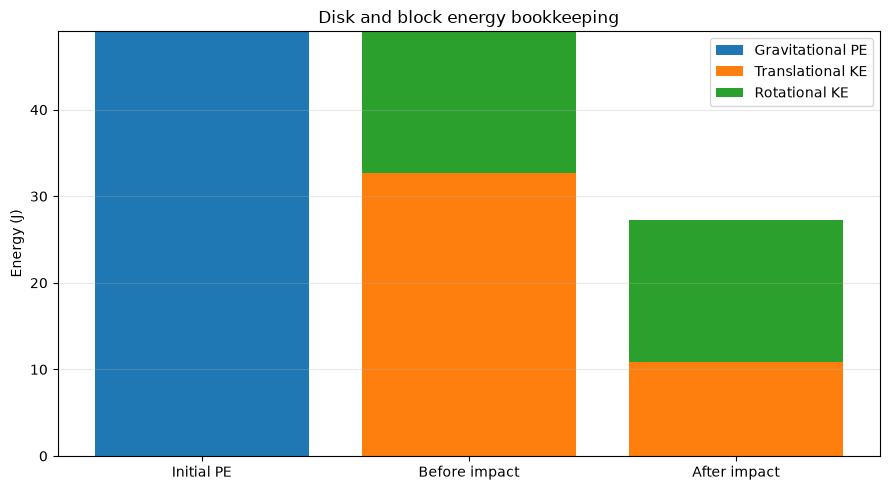

In [8]:
disk_mass = 1.0
block_mass = 2.0
disk_radius = 0.20
disk_c = 0.5
ramp_height = ramp_length * np.sin(incline_angle)
disk_inertia = disk_c * disk_mass * disk_radius**2

# Energy at the bottom of the ramp, starting from rest.
disk_speed_before = np.sqrt(2 * g * ramp_height / (1 + disk_c))
disk_spin_before = disk_speed_before / disk_radius
disk_translational_before = 0.5 * disk_mass * disk_speed_before**2
disk_rotational_before = 0.5 * disk_inertia * disk_spin_before**2
disk_potential_initial = disk_mass * g * ramp_height

# Perfectly inelastic translation; the simple model applies no impact torque.
shared_speed_after = disk_mass * disk_speed_before / (disk_mass + block_mass)
disk_spin_after = disk_spin_before
disk_translational_after = 0.5 * disk_mass * shared_speed_after**2
block_translational_after = 0.5 * block_mass * shared_speed_after**2
disk_rotational_after = 0.5 * disk_inertia * disk_spin_after**2
total_kinetic_before = disk_translational_before + disk_rotational_before
total_kinetic_after = (
    disk_translational_after + block_translational_after + disk_rotational_after
)

print(f"Disk speed before impact: {disk_speed_before:.3f} m/s")
print(f"Disk spin before impact: {disk_spin_before:.3f} rad/s")
print(f"Shared speed after impact: {shared_speed_after:.3f} m/s")
print(f"Disk spin after impact: {disk_spin_after:.3f} rad/s")
print(f"Initial gravitational PE: {disk_potential_initial:.3f} J")
print(f"Kinetic energy before impact: {total_kinetic_before:.3f} J")
print(f"Kinetic energy after impact: {total_kinetic_after:.3f} J")
print(f"Energy lost in impact: {total_kinetic_before - total_kinetic_after:.3f} J")

energy_labels = [
    "Initial PE",
    "Before impact",
    "After impact",
]
energy_values = [
    [disk_potential_initial, 0.0, 0.0],
    [0.0, disk_translational_before, disk_rotational_before],
    [0.0, disk_translational_after + block_translational_after, disk_rotational_after],
]
energy_values = np.asarray(energy_values)
energy_x = np.arange(len(energy_labels))

fig_collision, axis_collision = plt.subplots(figsize=(9, 5))
axis_collision.bar(energy_x, energy_values[:, 0], label="Gravitational PE")
axis_collision.bar(
    energy_x,
    energy_values[:, 1],
    bottom=energy_values[:, 0],
    label="Translational KE",
)
axis_collision.bar(
    energy_x,
    energy_values[:, 2],
    bottom=energy_values[:, 0] + energy_values[:, 1],
    label="Rotational KE",
)
axis_collision.set_xticks(energy_x, energy_labels)
axis_collision.set_ylabel("Energy (J)")
axis_collision.set_title("Disk and block energy bookkeeping")
axis_collision.grid(axis="y", alpha=0.3)
axis_collision.legend()
fig_collision.tight_layout()
plt.show()

### Interpretation

The disk starts from rest at height $h=L\sin\theta$, so its gravitational potential energy becomes translational and rotational kinetic energy:

$$
mgh = \frac{1}{2}mv^2 + \frac{1}{2}I\omega^2,
\qquad I=cmR^2,
\qquad v=R\omega.
$$

For the disk, $c=0.5$, giving $v=8.087$ m/s and $\omega=40.435$ rad/s at the bottom. I modeled the impact as perfectly inelastic in translation: the disk and block share a common speed after impact, found from translational momentum conservation. I assumed the collision exerts no impulsive torque on the disk, so its angular speed does not change. Therefore, **the disk keeps spinning after impact**, but it is no longer rolling without slipping because its translational speed has been reduced while its spin has not.

The initial potential energy and the kinetic energy just before impact agree at $49.050$ J. After impact, the disk and block have $27.250$ J of kinetic energy; the missing $21.800$ J is energy converted to deformation, sound, and heat in the inelastic collision. Rotational kinetic energy is included in both before/after totals and remains unchanged in this simple model.

A realistic model would need a finite contact time, normal deformation, friction between the disk and block, and friction with the flat surface. Contact friction can exert a torque and change the disk's spin, while also changing the translational impulse. The post-impact motion could include slipping followed by rolling again, with thermal energy generated during that process. Consequently, whether the disk continues spinning, reverses, or eventually rolls without slipping depends on the collision geometry, coefficient of restitution, friction coefficients, and the torque during contact.